<a href="https://colab.research.google.com/github/turkson-michael/Machine-learning-/blob/main/Multi_class_Exercise_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

In [ ]:
# Setting up device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [ ]:
# setting random seed
RANDOM_SEED= 42

In [ ]:
# Create a dataset with Scikit-Learn's make_moons()
from sklearn.datasets import make_moons

In [ ]:
X,y = make_moons(n_samples=1000, noise=0.5, random_state= 42)

In [ ]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
    "X2": X[:, 1],
    "label": y
})
circles.head(10)

,X1,X2,label
0,-0.292257,0.748299,1
1,1.474549,-0.111086,1
2,0.578556,0.718712,1
3,-0.419246,-0.861720,1
4,-0.765547,0.570814,0
5,0.808923,0.389684,1
6,0.238554,-0.155785,1
7,-0.293911,0.712411,1
8,1.476825,-0.431164,1
9,0.927035,1.272835,0


In [ ]:
# Check different labels
circles.label.value_counts()

,count
label,
1,500
0,500


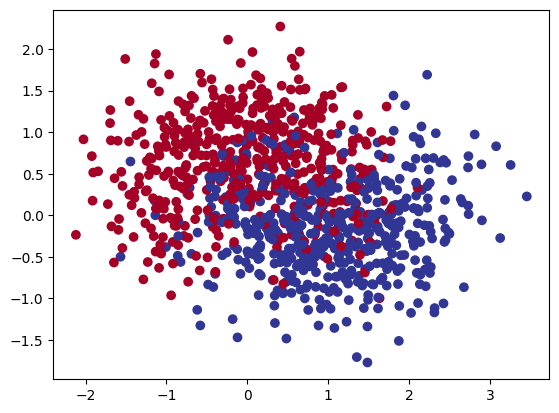

In [ ]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu);

In [ ]:
# convert it into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [ ]:
X.shape,y.shape

(torch.Size([1000, 2]), torch.Size([1000]))

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [ ]:
len(X_train), len(y_train)

(800, 800)

# Building a model

In [ ]:
class Moonmodel(nn.Module):
     def __init__(self):
         super().__init__()
         self.layer1 = nn.Linear(in_features= 2, out_features=10)
         self.layer2 = nn.Linear(in_features=10, out_features=10)
         self.layer3 = nn.Linear(in_features=10, out_features=1)
         self.relu = nn.ReLU()



     def forward(self,x):
         return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

model2 = Moonmodel()
model2

Moonmodel(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

# Loss & optimization function

In [ ]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD( params= model2.parameters(), lr=0.1)

In [ ]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return acc

# Training loop

In [ ]:
torch.manual_seed(42)

epochs = 1000

for epoch in range(epochs):
    # Training
    model2.train()
    #1. Forward
    y_logits = model2(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    #2. Calculate loss and accuracy
    loss = loss_fn( y_logits, y_train)
    acc = accuracy_fn(y_true= y_train, y_pred=y_pred)

    #3. Zero grad
    optimizer.zero_grad()

    #4. Back propagation
    loss.backward()

    #5. Step
    optimizer.step()

    ### Testing
    model2.eval()
    with torch.inference_mode():
         test_logits = model2(X_test).squeeze()
         test_preds = torch.round(torch.sigmoid(test_logits))

         # Calculate loss and accuracy
         test_loss = loss_fn(test_logits,y_test)
         test_acc = accuracy_fn( y_true= y_test, y_pred = test_preds)

    # Print out what's happening every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.32197, Accuracy: 85.75% | Test loss: 1.21561, Test acc: 80.00%
Epoch: 10 | Loss: 0.32198, Accuracy: 85.75% | Test loss: 1.21550, Test acc: 80.00%
Epoch: 20 | Loss: 0.32200, Accuracy: 85.75% | Test loss: 1.21546, Test acc: 80.00%
Epoch: 30 | Loss: 0.32201, Accuracy: 85.62% | Test loss: 1.21538, Test acc: 80.00%
Epoch: 40 | Loss: 0.32198, Accuracy: 85.62% | Test loss: 1.21525, Test acc: 80.00%
Epoch: 50 | Loss: 0.32197, Accuracy: 85.75% | Test loss: 1.21571, Test acc: 80.00%
Epoch: 60 | Loss: 0.32200, Accuracy: 85.50% | Test loss: 1.21550, Test acc: 80.00%
Epoch: 70 | Loss: 0.32200, Accuracy: 85.75% | Test loss: 1.21528, Test acc: 80.00%
Epoch: 80 | Loss: 0.32197, Accuracy: 85.62% | Test loss: 1.21526, Test acc: 80.00%
Epoch: 90 | Loss: 0.32198, Accuracy: 85.62% | Test loss: 1.21559, Test acc: 80.00%
Epoch: 100 | Loss: 0.32204, Accuracy: 85.50% | Test loss: 1.21535, Test acc: 80.00%
Epoch: 110 | Loss: 0.32197, Accuracy: 85.62% | Test loss: 1.21569, Test acc: 80.00%
Epo

In [ ]:
# Predictions using the model parameters
model2.eval()
with torch.inference_mode():
     test_pred = torch.round(torch.sigmoid(model2(X_test))).squeeze()

torch.eq(test_pred[:5],y_test[:5])
# test_pred[:5], y_test[:5]

tensor([ True, False,  True,  True,  True])

In [ ]:
# Plot the model predictions
import numpy as np

def plot_decision_boundary(model, X, y):

    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Source - https://madewithml.com/courses/foundations/neural-networks/
    # (with modifications)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101),
                         np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits)) # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

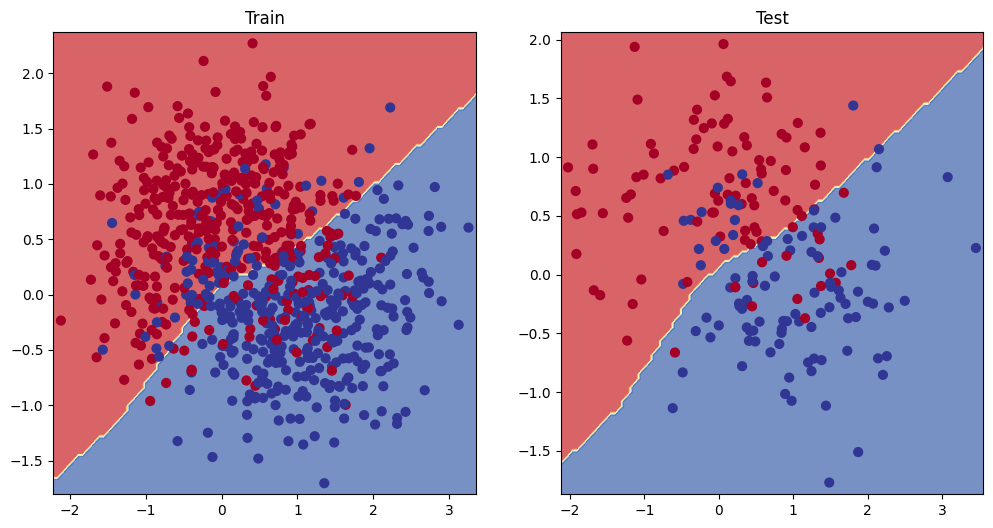

In [ ]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model2, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model2, X_test, y_test)

In [ ]:
# Let's calculuate the accuracy using accuracy from TorchMetrics
!pip -q install torchmetrics # Colab doesn't come with torchmetrics
from torchmetrics import Accuracy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.9 MB/s eta 0:00:00


In [ ]:
# TODO: Uncomment this code to use the Accuracy function
acc_fn = Accuracy(task="multiclass", num_classes=2).to(device) # send accuracy function to device
acc_fn

MulticlassAccuracy()

In [ ]:
acc_fn(test_preds, y_test) *100

tensor(81.)